In [345]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
print(f"- Semilla utilizada: {SEED}")
np.random.seed(SEED)

- Semilla utilizada: 42


# Ejercicio 1 - Simulación Monte Carlo

Tarea 1
---
- Escribir un código en Python que genere $N$ muestras uniformemente distribuidas en $[0,1]^2$ y calcule el número de ellas que están dentro del cuadrante de radio 1.

In [346]:
def generate_samples(N: int) -> tuple[np.ndarray, np.ndarray]:
    samples = np.random.rand(N, 2)
    x = samples[:, 0]
    y = samples[:, 1]
    return x, y

def samples_inside_mask(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return x**2 + y**2 <= 1.0

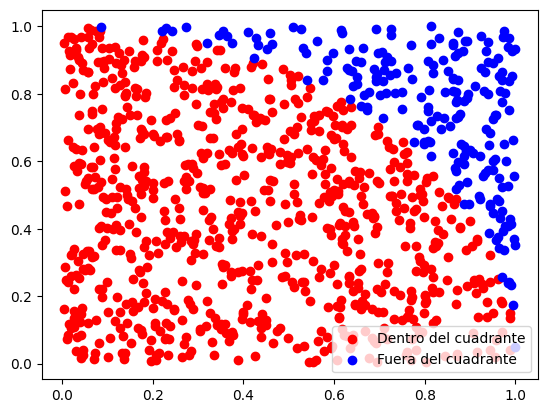

- Número de muestras dentro del cuadrante: 793


In [347]:
# Establecemos el número de muestras a generar
N = 1000
x, y = generate_samples(N)
mask = samples_inside_mask(x, y)
num_samples_inside = int(mask.sum())

# Mostramos gráfico y el número de muestras dentro del cuadrante
plt.scatter(x[mask], y[mask], color="red", label="Dentro del cuadrante")
plt.scatter(x[~mask], y[~mask], color="blue", label="Fuera del cuadrante")
plt.legend()
plt.show()

print(f"- Número de muestras dentro del cuadrante: {num_samples_inside}")

Tarea 2
---
A partir de ello, calcular $\hat{\pi}$, es decir la estimación del valor de $\pi$.

In [348]:
pi_hat = 4 * (num_samples_inside / N)
print(f"- Valor estimado de pi: {pi_hat}")

- Valor estimado de pi: 3.172


Tarea 3
---
Modifica a la baja $N$, ¿cuál piensas que es el número más pequeño para tener una buena estimación? ¿5, 10, 20, 50, ...?

In [349]:
N = 1000
print("- Encontrar valor mínimo de N para predecir pi:")
while N > 0:
    x, y = generate_samples(N)
    mask = samples_inside_mask(x, y)
    num_samples_inside = int(mask.sum())
    pi_hat = 4 * (num_samples_inside / N)
    print(f"    - Con N={N} la estimación es: {pi_hat}")
    N -= 50

- Encontrar valor mínimo de N para predecir pi:
    - Con N=1000 la estimación es: 3.168
    - Con N=950 la estimación es: 3.166315789473684
    - Con N=900 la estimación es: 3.168888888888889
    - Con N=850 la estimación es: 3.28
    - Con N=800 la estimación es: 3.225
    - Con N=750 la estimación es: 3.088
    - Con N=700 la estimación es: 3.1542857142857144
    - Con N=650 la estimación es: 3.126153846153846
    - Con N=600 la estimación es: 3.1333333333333333
    - Con N=550 la estimación es: 3.061818181818182
    - Con N=500 la estimación es: 3.144
    - Con N=450 la estimación es: 2.888888888888889
    - Con N=400 la estimación es: 3.2
    - Con N=350 la estimación es: 3.0285714285714285
    - Con N=300 la estimación es: 3.1466666666666665
    - Con N=250 la estimación es: 3.04
    - Con N=200 la estimación es: 3.06
    - Con N=150 la estimación es: 2.9066666666666667
    - Con N=100 la estimación es: 3.0
    - Con N=50 la estimación es: 3.04


Tarea 4
---
Realiza la simulación $K$ veces y calcula la media y varianza de $\hat{\pi}$.

In [350]:
K = 20
N = 1000
pi_hats = []
for _ in range(K):
    x, y = generate_samples(N)
    mask = samples_inside_mask(x, y)
    num_samples_inside = int(mask.sum())
    pi_hat = 4 * (num_samples_inside / N)
    pi_hats.append(pi_hat)

pi_hats = np.array(pi_hats, dtype=np.float32)
print(f"- Media: {np.mean(pi_hats)}")
print(f"- Varianza: {np.var(pi_hats)}")

- Media: 3.1488001346588135
- Varianza: 0.0027097617276012897


Tarea 5
---
Repite la tarea anterior con otros valores de $N$ (mayores y menores) y compara la varianza.

In [351]:
# Instanciamos una diccionario para almacenar los valores de varianza y compararlos
var_values = {}
K = 20
N_values = list(range(500, 20000, 500))
for N in N_values:
    pi_hats = []
    for _ in range(K):
        x, y = generate_samples(N)
        mask = samples_inside_mask(x, y)
        num_samples_inside = int(mask.sum())
        pi_hat = 4 * (num_samples_inside / N)
        pi_hats.append(pi_hat)

    pi_hats = np.array(pi_hats, dtype=np.float32)
    var = np.var(pi_hats)
    var_values[str(N)] = float(var)

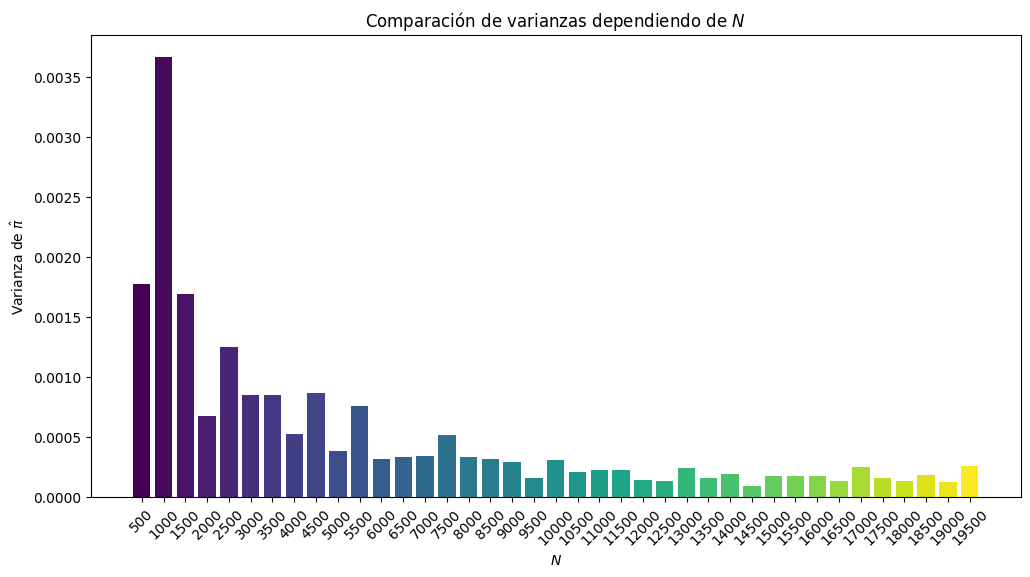

In [352]:
keys_int = sorted([int(k) for k in var_values.keys()])

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(min(keys_int), max(keys_int))
colors = cmap(norm(keys_int))

plt.figure(figsize=(12, 6))
plt.bar(var_values.keys(), var_values.values(), color=colors)
plt.xticks(rotation=45)
plt.xlabel(r"$N$")
plt.ylabel(r"Varianza de $\hat{\pi}$")
plt.title(r"Comparación de varianzas dependiendo de $N$")
plt.show()

### Reflexión
> Podemos observar que, a medida que aumenta el número de muestras a generar $N$ disminuye la varianza de la distribución $\hat{\pi}$. Esto nos indica que la varianza de la distribución tiende a disminuir a medida que aumentamos el número de muestras a generar ($N$), por lo que podemos establecer que cuantas más muestras generemos, habrá menor incertidumbre respecto al valor estimado de $\pi$ (la media de la distribución).